# Example 2 (acrobot manipulator) — publication figures

Mirror of the Dubins figure notebook. Four equal-aspect plots tile 4-across:
three per-method success panels (Vanilla MPC / Unconstrained reach-avoid /
RA-MPC) each with the shared-$x_0$ trajectory in end-effector space, plus one
3-row comparison figure (RA-MPC success rate vs $T_s$, then $\tau_1,\tau_2$
control comparison). Style follows `notebooks/`. Needs casadi+scipy+sympy
(env `rab_mpc`).


## §0 — Imports, paths, palette, constants


In [69]:
import importlib.util, json, os, warnings
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
CTRL = os.path.join(REV, "controllers")
REV_DATA = os.path.join(REV, "data")

import sys as _sys

_pp = os.path.join(ROOT, "python")
if _pp not in _sys.path:
    _sys.path.insert(0, _pp)
from functional import BetterColor  # gray0 palette (matches the example notebooks)

BASE_DT = 0.01
N_HOR_BASE = 20
PHI_TOL = 0.05
T_MAX = 10.0
T_MAX_UNCON = 8.0
TARGET_POS = np.array([5.8, 1.9])  # target ellipse centre in y-space
FS = 26
# palette (matches notebooks/)
C_SAFE = "#b2182b"
C_TARGET = "#d6604d"
C_SUCC = "#2166ac"
C_FAIL = "#d73027"
C_START = (1.0, 0.549, 0.0)
C_END = (0.102, 0.596, 0.314)  # orange3, green0
C_UNCON = "#2166ac"
C_PROP = "#8856a7"
C_BOUND = "#636363"
print("ROOT:", ROOT)

ROOT: /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC


## §1 — Controllers (RA-MPC cert + bounds, unconstrained FL law), sets, dynamics


In [70]:
with open(os.path.join(REV_DATA, "phase1_3_meta_manipulator.json")) as fh:
    meta = json.load(fh)
U_MAX = [float(meta["u_max_eff"]["tau1"]), float(meta["u_max_eff"]["tau2"])]
u1_max, u2_max = U_MAX
CONST = json.load(open(os.path.join(REV_DATA, "phase1_2_outputs_manipulator.json")))[
    "system_constants"
]
m1, m2 = CONST["m1"], CONST["m2"]
l1, l2 = CONST["l1"], CONST["l2"]
lc1, lc2 = CONST["lc1"], CONST["lc2"]
I1, I2 = CONST["I1"], CONST["I2"]
g_grav = CONST["g"]

x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, x3, x4]


def _load(p):
    spec = importlib.util.spec_from_file_location(os.path.basename(p)[:-3], p)
    m = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(m)
    return m


ra_mod = _load(os.path.join(CTRL, "manipulator_constrained.py"))
cert = sp.sympify(ra_mod.certificate_opt)
unc_mod = _load(os.path.join(CTRL, "manipulator_unconstrained.py"))
u_unc = [sp.lambdify(state_vars, ui, "numpy") for ui in sp.Matrix(unc_mod.u_opt)]


def u_unc_of(x):
    return np.array([float(np.squeeze(f(*x))) for f in u_unc])


def h_np(x_):
    q1, q2 = x_[0], x_[1]
    return np.array(
        [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l1 * np.sin(q1) + l2 * np.sin(q1 + q2)]
    )


def psi_y(a, b):  # safe: psi >= 0
    return -((4 * (a - 2) - 2 * b**3) ** 2) + 0.8 * b**3 + 10


def phi_y(a, b):  # target: phi <= 0
    return ((a - 2 - 3.5) ** 2 / 1.2**2) + ((b - 1.8) ** 2 / 0.4**2) - 2


def psi_x(x_):
    y = h_np(x_)
    return psi_y(y[0], y[1])


def phi_x(x_):
    y = h_np(x_)
    return phi_y(y[0], y[1])


def acrobot_rhs_np(t, x_, u_):
    q1, q2, dq1, dq2 = x_
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2
    M = np.array([[M11, M12], [M12, m2 * lc2**2 + I2]])
    C = np.array(
        [
            [
                -m2 * l1 * lc2 * np.sin(q2) * dq2,
                -m2 * l1 * lc2 * np.sin(q2) * (dq1 + dq2),
            ],
            [m2 * l1 * lc2 * np.sin(q2) * dq1, 0.0],
        ]
    )
    G = np.array(
        [
            (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1)
            + m2 * g_grav * lc2 * np.cos(q1 + q2),
            m2 * g_grav * lc2 * np.cos(q1 + q2),
        ]
    )
    qddot = np.linalg.solve(M, -C @ np.array([dq1, dq2]) - G + np.asarray(u_))
    return [dq1, dq2, qddot[0], qddot[1]]


def inverse_kinematics(a, b, L1, L2):
    r2 = a**2 + b**2
    cq2 = (r2 - L1**2 - L2**2) / (2 * L1 * L2)
    q2a = np.arccos(cq2)
    phi = np.arctan2(b, a)
    q1a = phi - np.arctan2(L2 * np.sin(q2a), L1 + L2 * np.cos(q2a))
    return (q1a, q2a)


print("u_max_eff =", U_MAX, "| l1+l2 =", l1 + l2)

u_max_eff = [679.2, 500.1] | l1+l2 = 8.0


## §2 — Candidate set (seed 42, output-space + IK) + cached sweep success


In [71]:
# reproduce the sweep candidate sampling EXACTLY (seed 42, same draw order)
np.random.seed(42)
N_pool = 2000
y1s = np.random.uniform(-1.0, 5.5, N_pool)
y2s = np.random.uniform(-4.0, 3.1, N_pool)
xl = []
for i in range(N_pool):
    r2 = y1s[i] ** 2 + y2s[i] ** 2
    if r2 > (l1 + l2) ** 2 or r2 < 1e-4:
        xl.append([np.nan] * 4)
        continue
    q1, q2 = inverse_kinematics(y1s[i], y2s[i], l1, l2)
    xl.append(
        [q1, q2, 0.0, 0.0] if (np.isfinite(q1) and np.isfinite(q2)) else [np.nan] * 4
    )
X = np.array(xl).T
valid = np.all(np.isfinite(X), axis=0)
psi_v = np.array([psi_x(X[:, i]) if valid[i] else -np.inf for i in range(N_pool)])
phi_v = np.array([phi_x(X[:, i]) if valid[i] else -np.inf for i in range(N_pool)])
cand_idx = np.where((psi_v >= 0) & (phi_v > 0))[0][:150]
x_cands = X[:, cand_idx]
Ncand = x_cands.shape[1]
Y0 = np.array([h_np(x_cands[:, i]) for i in range(Ncand)]).T  # (2, Ncand)

raw = pd.read_csv(os.path.join(REV_DATA, "manipulator_sweep_raw.csv"))


def _mask(method):
    s = raw[(raw.method == method) & (np.isclose(raw.dt_mpc, BASE_DT))].sort_values(
        "cand_id"
    )
    return s["success"].values.astype(bool)


succ = {"Vanilla MPC": _mask("Vanilla MPC"), "RA-MPC (ours)": _mask("RA-MPC (ours)")}
print(
    "from sweep CSV @ dt=%.3f:  Vanilla %d/%d,  RA-MPC %d/%d"
    % (BASE_DT, succ["Vanilla MPC"].sum(), Ncand, succ["RA-MPC (ours)"].sum(), Ncand)
)

from sweep CSV @ dt=0.010:  Vanilla 113/150,  RA-MPC 120/150


## §3 — Unconstrained closed-loop success (computed + cached)


In [72]:
UNC_CSV = os.path.join(REV_DATA, "manipulator_uncon_success.csv")
REGEN_UNC = False


def uncon_rollout(x0, t_max=T_MAX_UNCON):
    def rhs(t, x):
        try:
            u = u_unc_of(x)
        except Exception:
            return np.zeros(4)
        if not np.all(np.isfinite(u)):
            return np.zeros(4)
        d = acrobot_rhs_np(t, x, u)
        d = np.asarray(d, float)
        return d if np.all(np.isfinite(d)) else np.zeros(4)

    def ev(t, x):
        return float(phi_x(x))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, t_max),
        np.asarray(x0, float),
        method="DOP853",
        events=ev,
        rtol=1e-6,
        atol=1e-8,
        max_step=BASE_DT,
        dense_output=True,
    )
    if not np.all(np.isfinite(s.y)):
        return False
    reached = s.status == 1
    ts = np.linspace(0, s.t[-1], max(2, int(s.t[-1] / (BASE_DT / 5)) + 1))
    xs = s.sol(ts)
    safe = bool(np.all([psi_x(xs[:, k]) >= -1e-9 for k in range(xs.shape[1])]))
    return bool(reached and safe)


if (not REGEN_UNC) and os.path.exists(UNC_CSV):
    um = pd.read_csv(UNC_CSV)
    if len(um) == Ncand and int(um["seed"].iloc[0]) == 42:
        succ["Uncon. reach-avoid"] = um["success"].values.astype(bool)
        print(
            "loaded cached unconstrained success:",
            succ["Uncon. reach-avoid"].sum(),
            "/",
            Ncand,
        )
if "Uncon. reach-avoid" not in succ:
    import time

    t0 = time.time()
    m = np.array([uncon_rollout(x_cands[:, i]) for i in range(Ncand)])
    pd.DataFrame({"cand_id": np.arange(Ncand), "success": m, "seed": 42}).to_csv(
        UNC_CSV, index=False
    )
    succ["Uncon. reach-avoid"] = m
    print(
        "computed unconstrained success: %d/%d  (%.0fs, cached)"
        % (m.sum(), Ncand, time.time() - t0)
    )

loaded cached unconstrained success: 135 / 150


## §4 — Shared $x_0$ (successful under all three) + roll out each method


In [73]:
# --- CasADi acrobot MPC (vanilla target terminal / RA-MPC cert terminal) ---
def _s2c(e, mp):
    if isinstance(
        e,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(e)
    if isinstance(e, sp.Symbol):
        return mp[e]
    if isinstance(e, sp.Add):
        return sum(_s2c(a, mp) for a in e.args)
    if isinstance(e, sp.Mul):
        r = 1.0
        for a in e.args:
            r = r * _s2c(a, mp)
        return r
    if isinstance(e, sp.Pow):
        return _s2c(e.args[0], mp) ** _s2c(e.args[1], mp)
    if isinstance(e, sp.sin):
        return ca.sin(_s2c(e.args[0], mp))
    if isinstance(e, sp.cos):
        return ca.cos(_s2c(e.args[0], mp))
    if isinstance(e, sp.Number):
        return float(e)
    raise ValueError(type(e))


cx1, cx2, cx3, cx4 = ca.SX.sym("x1"), ca.SX.sym("x2"), ca.SX.sym("x3"), ca.SX.sym("x4")
mp = {x1: cx1, x2: cx2, x3: cx3, x4: cx4}
cert_f = ca.Function("cert", [cx1, cx2, cx3, cx4], [_s2c(cert, mp)])


def cert_ca(xv):
    return cert_f(xv[0], xv[1], xv[2], xv[3])


def h_ca(xv):
    return ca.vertcat(
        l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1]),
        l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1]),
    )


def safe_ca(xv):
    a, b = h_ca(xv)[0], h_ca(xv)[1]
    return -((4 * (a - 2) - 2 * b**3) ** 2) + 0.8 * b**3 + 10


def target_ca(xv):
    a, b = h_ca(xv)[0], h_ca(xv)[1]
    return ((a - 2 - 3.5) ** 2 / 1.2**2) + ((b - 1.8) ** 2 / 0.4**2) - 2


xc = ca.MX.sym("x", 4)
uc = ca.MX.sym("u", 2)


def _acrobot_ca(x, u):
    q1, q2, dq1, dq2 = x[0], x[1], x[2], x[3]
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2
    M = ca.vertcat(ca.horzcat(M11, M12), ca.horzcat(M12, m2 * lc2**2 + I2))
    C = ca.vertcat(
        ca.horzcat(
            -m2 * l1 * lc2 * ca.sin(q2) * dq2, -m2 * l1 * lc2 * ca.sin(q2) * (dq1 + dq2)
        ),
        ca.horzcat(m2 * l1 * lc2 * ca.sin(q2) * dq1, ca.DM(0.0)),
    )
    G = ca.vertcat(
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1)
        + m2 * g_grav * lc2 * ca.cos(q1 + q2),
        m2 * g_grav * lc2 * ca.cos(q1 + q2),
    )
    qddot = ca.solve(M, -C @ ca.vertcat(dq1, dq2) - G + u)
    return ca.vertcat(dq1, dq2, qddot[0], qddot[1])


rhs_ca = ca.Function("f", [xc, uc], [_acrobot_ca(xc, uc)])


def F_disc(x, u, dt):
    k1 = rhs_ca(x, u)
    k2 = rhs_ca(x + dt / 2 * k1, u)
    k3 = rhs_ca(x + dt / 2 * k2, u)
    k4 = rhs_ca(x + dt * k3, u)
    return x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}


def solve_mpc(x0, dt, N, terminal, U_warm=None):
    opti = ca.Opti()
    X = opti.variable(4, N + 1)
    U = opti.variable(2, N)
    x0 = np.asarray(x0, float).flatten()
    opti.subject_to(X[:, 0] == x0)
    for k in range(N):
        opti.subject_to(X[:, k + 1] == F_disc(X[:, k], U[:, k], dt))
        opti.subject_to(safe_ca(X[:, k]) >= 0)
    opti.subject_to(safe_ca(X[:, N]) >= 0)
    if terminal == "target":
        opti.subject_to(target_ca(X[:, N]) <= 0)
    else:
        opti.subject_to(cert_ca(X[:, N]) >= 0)
    opti.subject_to(opti.bounded(-u1_max, U[0, :], u1_max))
    opti.subject_to(opti.bounded(-u2_max, U[1, :], u2_max))
    tgt = ca.DM(TARGET_POS)
    Q = ca.DM([[5.0, 0], [0, 5.0]])
    Qf = ca.DM([[80.0, 0], [0, 80.0]])
    R = ca.DM([[1e-3, 0], [0, 1e-3]])
    cost = 0
    for k in range(N):
        dy = h_ca(X[:, k]) - tgt
        cost += dy.T @ Q @ dy + U[:, k].T @ R @ U[:, k]
    dyN = h_ca(X[:, N]) - tgt
    cost += dyN.T @ Qf @ dyN
    opti.minimize(cost)
    if U_warm is not None:
        U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
        X_ws = np.zeros((4, N + 1))
        X_ws[:, 0] = x0
        for k in range(N):
            X_ws[:, k + 1] = np.asarray(
                F_disc(ca.DM(X_ws[:, k]), ca.DM(U_ws[:, k]), dt)
            ).flatten()
        opti.set_initial(X, X_ws)
        opti.set_initial(U, U_ws)
    else:  # cold start: linear interp x0 -> target pose, zero torque
        xtf = np.array([np.arctan2(TARGET_POS[1], TARGET_POS[0]), 0.0, 0.0, 0.0])
        X_ws = np.array([(1 - k / N) * x0 + (k / N) * xtf for k in range(N + 1)]).T
        opti.set_initial(X, X_ws)
        opti.set_initial(U, 0)
    opti.solver("ipopt", _OPTS)
    try:
        sol = opti.solve()
        return True, np.array(sol.value(U)).reshape(2, N)
    except Exception:
        return False, None


def rollout_mpc(x0, terminal, dt=BASE_DT, N=N_HOR_BASE):
    x = np.asarray(x0, float).copy()
    ts = [0.0]
    us = []
    xs = [x.copy()]
    t = 0.0
    U_prev = None
    while t < T_MAX - 1e-9:
        if float(phi_x(x)) <= PHI_TOL:
            break
        ok, U = solve_mpc(x, dt, N, terminal, U_prev)
        if not ok:
            break
        U_prev = U
        u0 = np.array(U[:, 0]).flatten()
        sol = solve_ivp(
            lambda _t, xx: acrobot_rhs_np(_t, xx, u0),
            [t, t + dt],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break
        x = sol.y[:, -1]
        t += dt
        us.append(u0)
        ts.append(t)
        xs.append(x.copy())
    return np.array(ts), np.array(us), np.array(xs)


def rollout_uncon(x0):
    x0 = np.asarray(x0, float)

    def rhs(t, x):
        try:
            u = u_unc_of(x)
        except Exception:
            return np.zeros(4)
        if not np.all(np.isfinite(u)):
            return np.zeros(4)
        d = np.asarray(acrobot_rhs_np(t, x, u), float)
        return d if np.all(np.isfinite(d)) else np.zeros(4)

    def ev(t, x):
        return float(phi_x(x))

    ev.terminal = True
    ev.direction = -1
    s = solve_ivp(
        rhs,
        (0, T_MAX_UNCON),
        x0,
        method="DOP853",
        events=ev,
        rtol=1e-8,
        atol=1e-10,
        max_step=BASE_DT,
        dense_output=True,
    )
    tf = float(s.t[-1])
    ts = np.linspace(0, tf, max(2, int(tf / (BASE_DT / 5)) + 1))
    xs = s.sol(ts).T
    us = np.array([u_unc_of(xx) for xx in xs])
    return ts, us, xs


def _rollout_ok(triple):
    tt, uu, xx = triple
    if len(uu) == 0:
        return False
    reached = float(phi_x(xx[-1])) <= PHI_TOL + 1e-6
    safe = bool(np.all([psi_x(xx[k]) >= -1e-6 for k in range(len(xx))]))
    return bool(reached and safe)


# shared x0: all-three-success, farthest-from-target, self-validating rollouts
all3 = succ["Vanilla MPC"] & succ["Uncon. reach-avoid"] & succ["RA-MPC (ours)"]
cols = np.where(all3)[0]
assert len(cols) > 0, "no x0 succeeds under all three methods"
order = cols[
    np.argsort(
        -((Y0[0, cols] - TARGET_POS[0]) ** 2 + (Y0[1, cols] - TARGET_POS[1]) ** 2)
    )
]
tj = None
x0_shared = None
x0_id = None
for cid in order:
    x0c = x_cands[:, cid]
    cand = {
        "Vanilla MPC": rollout_mpc(x0c, "target"),
        "RA-MPC (ours)": rollout_mpc(x0c, "cert"),
        "Uncon. reach-avoid": rollout_uncon(x0c),
    }
    if all(_rollout_ok(cand[m]) for m in cand):
        tj = cand
        x0_shared = x0c
        x0_id = int(cid)
        break
assert tj is not None, "no all-3-success x0 produced consistent rollouts"
print(
    "shared x0 (cand_id=%d):" % x0_id,
    np.round(x0_shared, 3),
    "| #all-3-success =",
    len(cols),
)
for k, (tt, uu, xx) in tj.items():
    print(f"  {k:20s}: {len(uu)} ctrl steps, reaches T_x at t={tt[-1]:.3f}s")

shared x0 (cand_id=79): [-1.757  2.815  0.     0.   ] | #all-3-success = 99
  Vanilla MPC         : 31 ctrl steps, reaches T_x at t=0.310s
  RA-MPC (ours)       : 61 ctrl steps, reaches T_x at t=0.610s
  Uncon. reach-avoid  : 530 ctrl steps, reaches T_x at t=1.060s


## §5 — Per-method success figures (scatter + shared-$x_0$ trajectory)

End-effector ($y$) space; style follows `notebooks/` cell 9. Saved as
`fig_manip_{vanilla,uncon,rampc}.png`, all the same figure size as the
comparison figure for an equal-height 4-across layout.


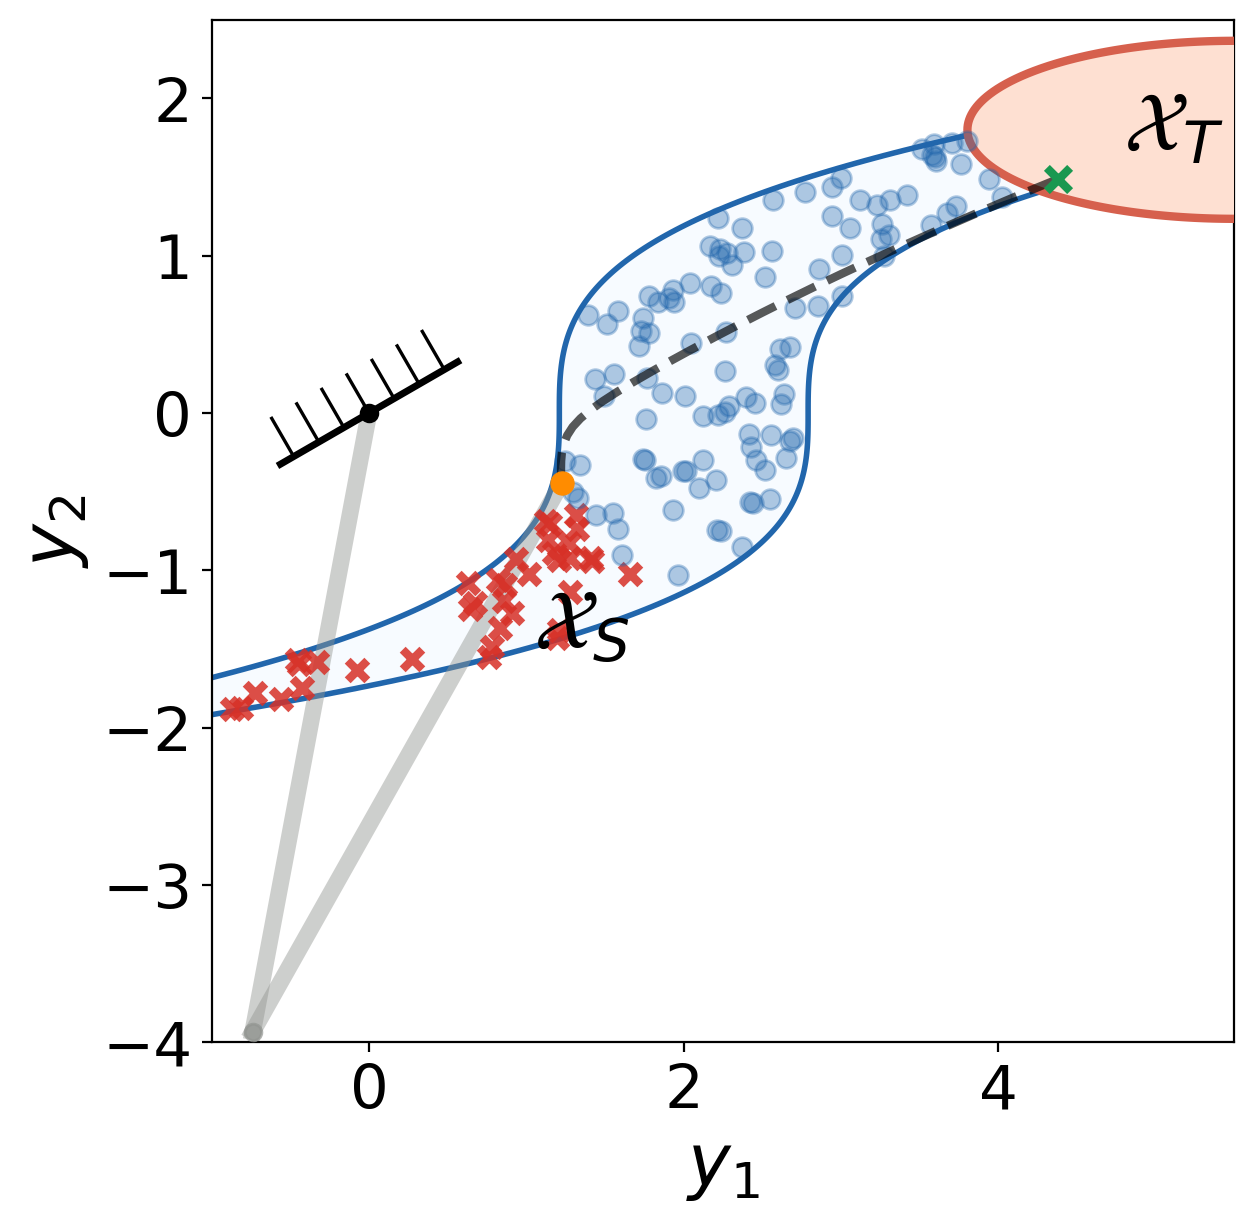

saved fig_manip_vanilla.png (success 113/150)


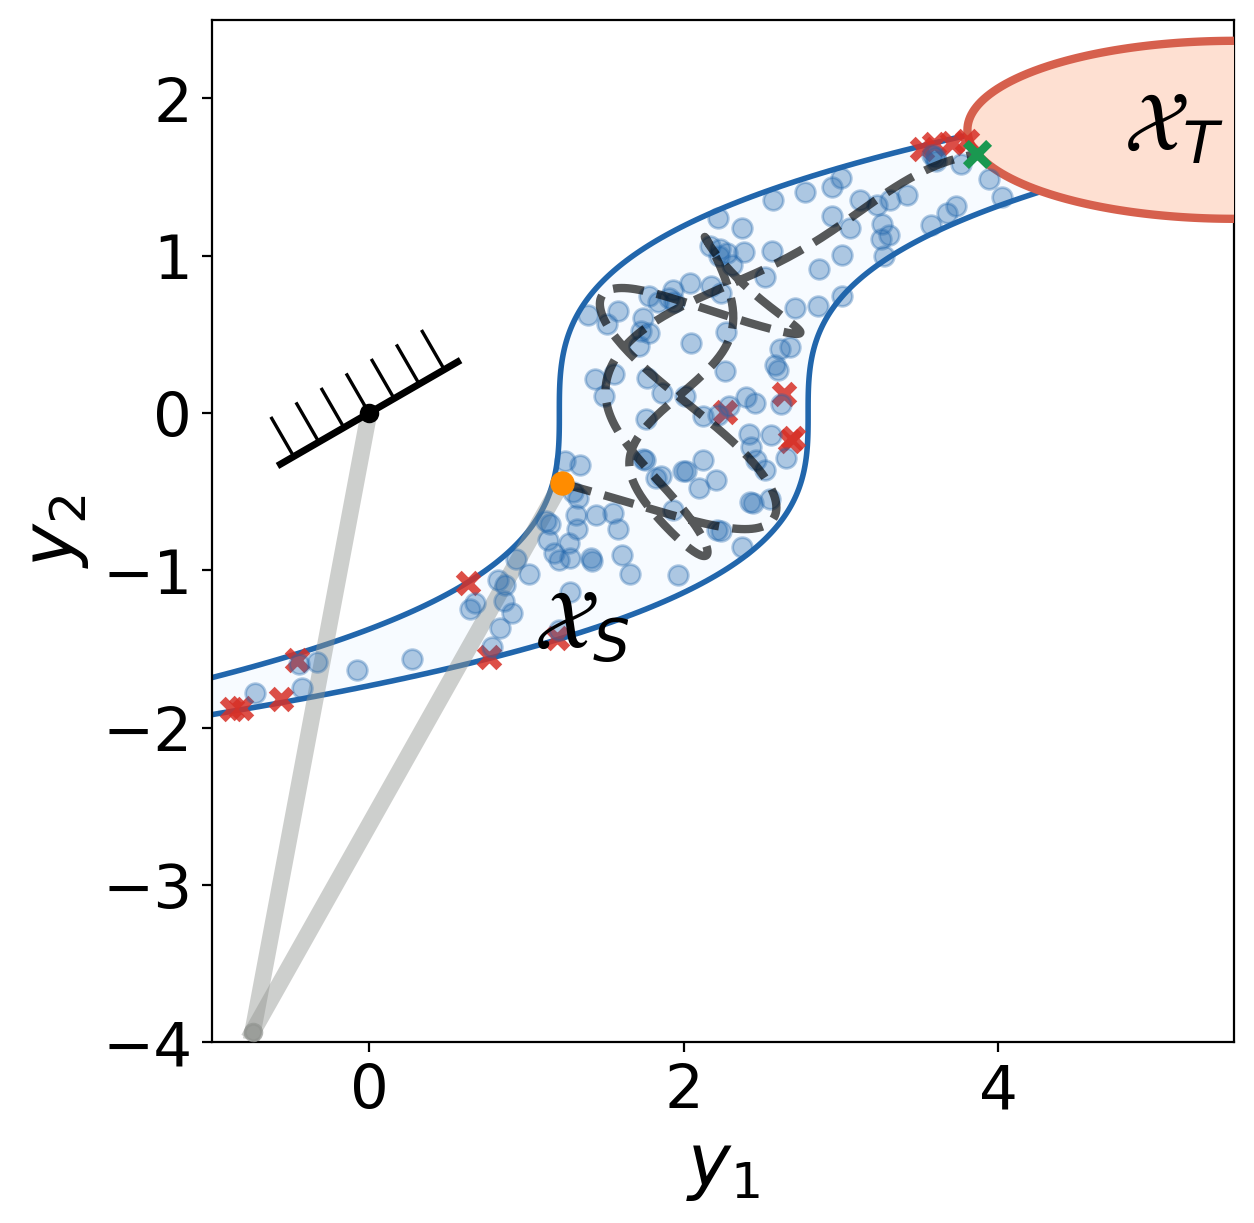

saved fig_manip_uncon.png (success 135/150)


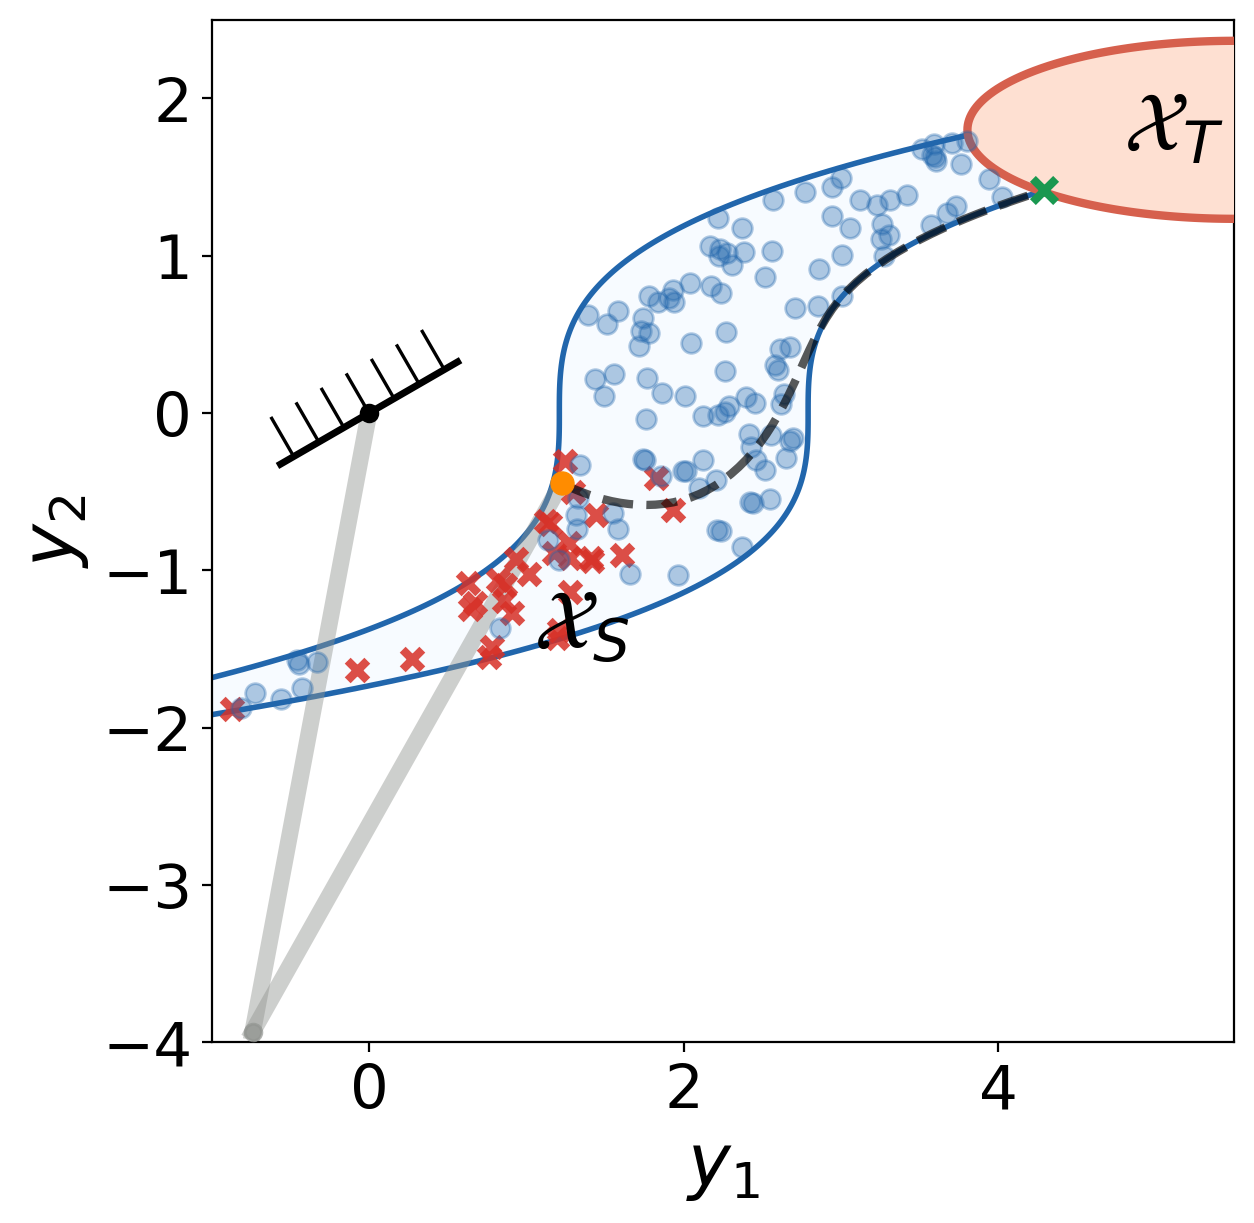

saved fig_manip_rampc.png (success 120/150)


In [74]:
g1 = np.linspace(-1.0, 5.5, 400)
g2 = np.linspace(-4.0, 2.5, 400)
G1, G2 = np.meshgrid(g1, g2)
Zs = psi_y(G1, G2)
Zt = phi_y(G1, G2)
px = 1 / plt.rcParams["figure.dpi"]
FS_P = 30

FILE = {
    "Vanilla MPC": "fig_manip_vanilla.png",
    "Uncon. reach-avoid": "fig_manip_uncon.png",
    "RA-MPC (ours)": "fig_manip_rampc.png",
}


def draw_sets(ax):
    ax.contourf(G1, G2, Zs, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1)
    ax.contour(G1, G2, Zs, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)
    ax.contourf(
        G1, G2, Zt, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1.0, zorder=3
    )
    ax.contour(G1, G2, Zt, levels=[0], colors=["#d6604d"], linewidths=3, zorder=4)


C_ARM = (146 / 255, 149 / 255, 145 / 255)  # gray2


def draw_robot(ax, x0):
    # two-link arm in its initial pose + angled 30deg base wall at the origin
    q1, q2 = float(x0[0]), float(x0[1])
    jx, jy = l1 * np.cos(q1), l1 * np.sin(q1)
    ex, ey = jx + l2 * np.cos(q1 + q2), jy + l2 * np.sin(q1 + q2)
    ax.plot([0, jx], [0, jy], "o-", alpha=0.45, lw=6, color=C_ARM, zorder=6)
    ax.plot([jx, ex], [jy, ey], "o-", alpha=0.45, lw=6, color=C_ARM, zorder=6)
    wall_hw, tick_len, n_ticks = 0.65, 0.28, 7
    th = np.radians(30)
    wd = np.array([np.cos(th), np.sin(th)])
    wp = np.array([-np.sin(th), np.cos(th)])
    p0, p1 = -wall_hw * wd, wall_hw * wd
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], "k-", lw=2.5, zorder=50)
    for sv in np.linspace(-wall_hw * 0.85, wall_hw * 0.85, n_ticks):
        b = sv * wd
        tp = b + tick_len * wp
        ax.plot([b[0], tp[0]], [b[1], tp[1]], "k-", lw=1.2, zorder=50)
    ax.plot(0, 0, "ko", markersize=6, zorder=51)


# ── k1(y) vector fields (output space) for the reach-avoid methods ──
vf_y1 = np.linspace(-1, 5.5, 22)
vf_y2 = np.linspace(-4, 3.1, 22)
VF_Y1, VF_Y2 = np.meshgrid(vf_y1, vf_y2)


def _k1_field(k1_opt):
    f = sp.lambdify([y1, y2], list(k1_opt), "numpy")

    def ev(Yg1, Yg2):
        vals = f(Yg1, Yg2)
        U = np.broadcast_to(np.asarray(vals[0], float), Yg1.shape).astype(float)
        V = np.broadcast_to(np.asarray(vals[1], float), Yg1.shape).astype(float)
        return U, V

    return ev


K1_FIELD = {
    "Uncon. reach-avoid": _k1_field(unc_mod.k1_opt),
    "RA-MPC (ours)": _k1_field(ra_mod.k1_opt),
}


for method in ["Vanilla MPC", "Uncon. reach-avoid", "RA-MPC (ours)"]:
    mask = succ[method]
    ns = int(mask.sum())
    tt, uu, xx = tj[method]
    Yt = np.array([h_np(xx[k]) for k in range(len(xx))]).T
    fig, ax = plt.subplots(figsize=(650 * px, 600 * px), layout="constrained")
    fig.set_dpi(200)
    # k1(y) vector field behind the sets (reach-avoid methods only)
    # if method in K1_FIELD:
    #     Uk, Vk = K1_FIELD[method](VF_Y1, VF_Y2)
    #     ax.streamplot(
    #         vf_y1,
    #         vf_y2,
    #         Uk,
    #         Vk,
    #         density=0.6,
    #         color=BetterColor.gray0(0.5),
    #         linewidth=0.8,
    #         arrowsize=0.8,
    #         zorder=0,
    #     )
    draw_sets(ax)
    draw_robot(ax, x0_shared)
    ax.scatter(
        Y0[0, ~mask],
        Y0[1, ~mask],
        s=50,
        color="#d73027",
        alpha=0.85,
        marker="x",
        linewidths=3,
        label="failure (%d)" % (Ncand - ns),
        zorder=8,
    )
    ax.scatter(
        Y0[0, mask],
        Y0[1, mask],
        s=50,
        color="#2166ac",
        alpha=0.35,
        marker="o",
        label="success (%d)" % ns,
        zorder=9,
    )
    ax.plot(Yt[0], Yt[1], color="black", lw=3, alpha=0.65, linestyle="--", zorder=10)
    ax.scatter(
        Yt[0, 0], Yt[1, 0], s=70, c=[C_START], marker="o", linewidths=0.4, zorder=20
    )
    ax.scatter(
        Yt[0, -1], Yt[1, -1], s=70, c=[C_END], marker="x", linewidths=3, zorder=20
    )
    fs = 30
    ax.text(0.95 + 0.1, -1.4 - 0.1, r"$\mathcal{X}_S$", zorder=100, fontsize=fs)
    ax.text(4.8, 1.67, r"$\mathcal{X}_T$", zorder=1000, fontsize=fs)
    ax.set_xlabel("$y_1$", fontsize=FS_P - 4)
    ax.set_ylabel("$y_2$", fontsize=FS_P - 4)
    ax.xaxis.set_tick_params(labelsize=22)
    ax.yaxis.set_tick_params(labelsize=22)
    ax.set_xlim(-1.0, 5.5)
    ax.set_ylim(-4.0, 2.5)
    ax.set_aspect("equal")
    # ax.legend(fontsize=16, loc="lower left")
    fig.savefig(os.path.join(REV_DATA, FILE[method]), dpi=200)
    plt.show()
    print("saved", FILE[method], "(success %d/%d)" % (ns, Ncand))

## §6 — Comparison figure (RA-MPC sweep + control inputs)

Vertical 3-row stack (same size as the per-method panels). Top: RA-MPC success
rate vs $T_s$. Bottom: $\tau_1,\tau_2$ for the shared $x_0$ — unconstrained
(continuous, blue) vs RA-MPC (ZOH step, purple) against $\pm$bounds. Saved as
`fig_manip_compare.png`.


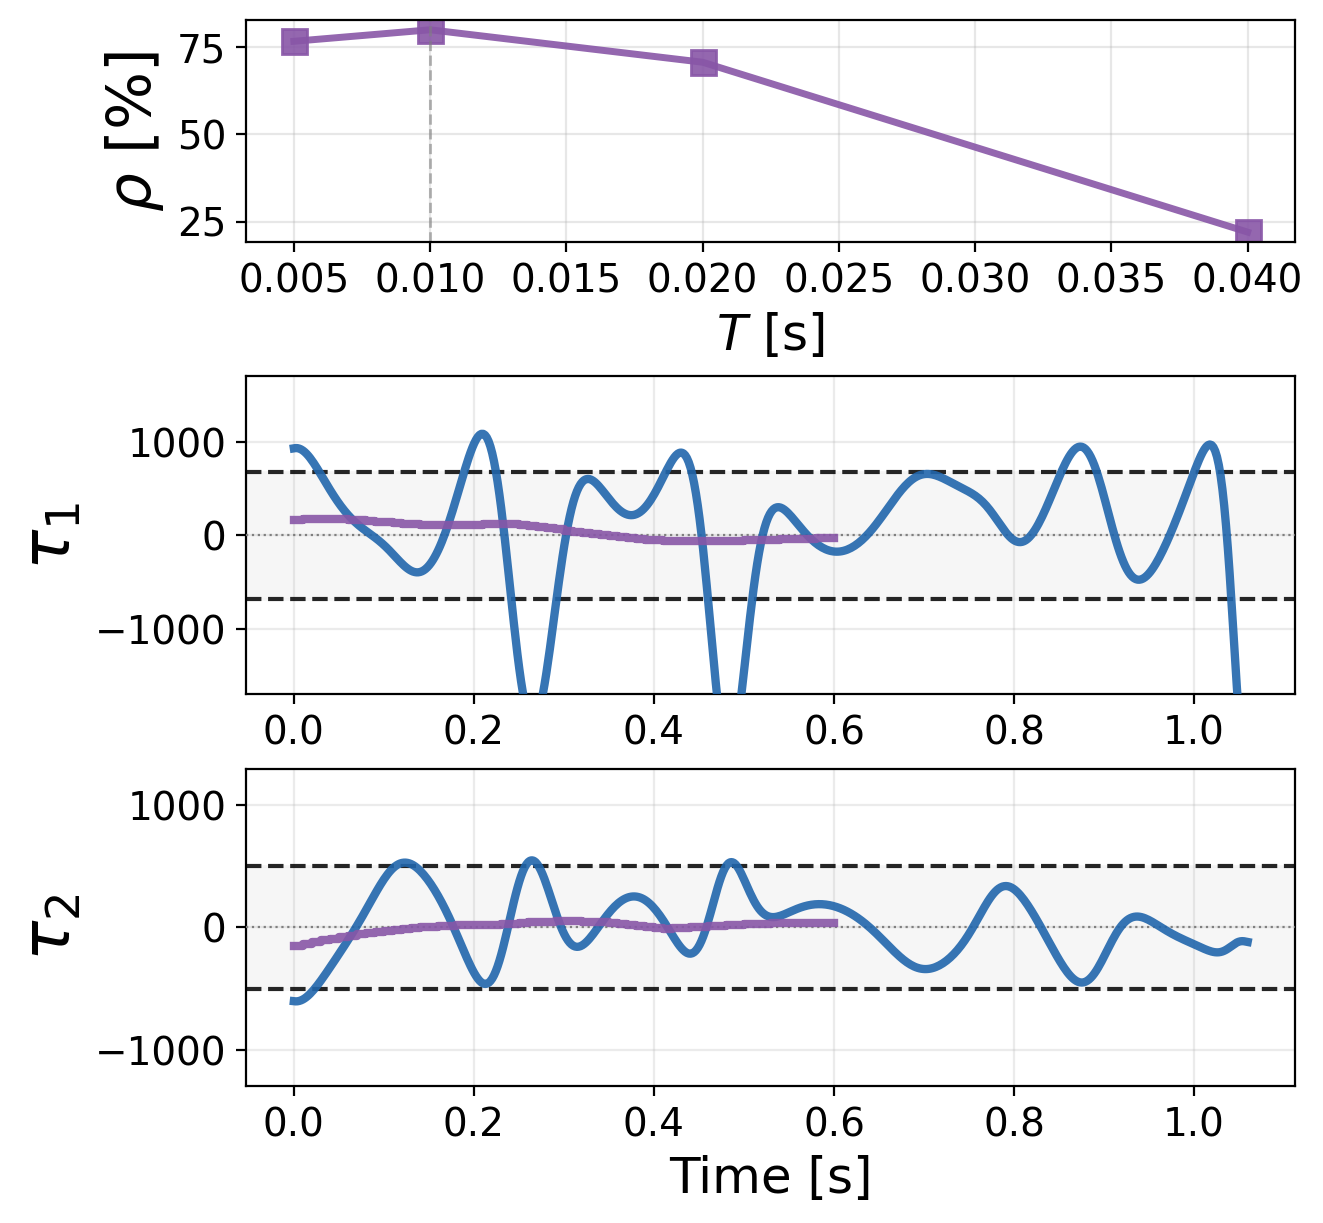

saved fig_manip_compare.png


In [75]:
summary = pd.read_csv(os.path.join(REV_DATA, "manipulator_sweep_summary.csv"))
tu, uu_u, _xu = tj["Uncon. reach-avoid"]
tr, uu_r, _xr = tj["RA-MPC (ours)"]
px = 1 / plt.rcParams["figure.dpi"]
FS_C = 24

fig, (axR, axW, axA) = plt.subplots(
    3,
    1,
    figsize=(650 * px, 600 * px),
    layout="constrained",
    gridspec_kw={"height_ratios": [0.7, 1.0, 1.0]},
)
fig.set_dpi(200)

sub = summary[summary["method"] == "RA-MPC (ours)"].sort_values("dt_mpc")
axR.plot(
    sub["dt_mpc"],
    sub["success_rate"],
    color="#8856a7",
    marker="s",
    lw=2.5,
    ms=9,
    alpha=0.9,
)
axR.axvline(BASE_DT, color="gray", lw=1, ls="--", alpha=0.6)
axR.set_xlabel("$T$ [s]", fontsize=FS_C - 6)
axR.set_ylabel(r"$\rho$ [%]", fontsize=FS_C - 2)
axR.xaxis.set_tick_params(labelsize=14)
axR.yaxis.set_tick_params(labelsize=14)
axR.grid(True, alpha=0.3)

YLIM = {0: (-1700, 1700), 1: (-1300, 1300)}
for ax, ch, ub, lbl in zip((axW, axA), (0, 1), U_MAX, (r"$\tau_1$", r"$\tau_2$")):
    ax.axhspan(-ub, ub, color="#f0f0f0", alpha=0.6, zorder=0)
    ax.axhline(ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(-ub, color="black", lw=1.5, ls="--", alpha=0.85, zorder=5)
    ax.axhline(0, color="gray", lw=0.8, ls=":", zorder=4)
    ax.plot(
        tu,
        uu_u[:, ch],
        color="#2166ac",
        lw=3,
        alpha=0.9,
        zorder=10,
        label="unconstrained",
    )
    ax.step(
        tr[:-1],
        uu_r[:, ch],
        where="post",
        color="#8856a7",
        lw=3,
        alpha=0.9,
        zorder=10,
        label="RA-MPC (ours)",
    )
    ax.set_ylabel(lbl, fontsize=FS_C)
    ax.set_ylim(*YLIM[ch])
    ax.xaxis.set_tick_params(labelsize=14)
    ax.yaxis.set_tick_params(labelsize=14)
    ax.grid(True, alpha=0.25)
axA.set_xlabel("Time [s]", fontsize=FS_C - 6)
# axA.legend(fontsize=11, loc="upper right", ncol=1)
fig.savefig(os.path.join(REV_DATA, "fig_manip_compare.png"), dpi=200)
plt.show()
print("saved fig_manip_compare.png")